In [216]:
import warnings
warnings.filterwarnings('ignore')

In [217]:
import pandas as pd
import numpy as np
import pyreadr
import joblib
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import plotly.express as px

from tqdm import tqdm

from dash import Dash, html, dcc, dash_table, Input, Output, callback
import dash_bootstrap_components as dbc

In [218]:
pd.set_option('display.max_columns', 100)

In [219]:
dem_uncont = 34
rep_uncont = 31

In [220]:
seat_sims = pyreadr.read_r('model_output/tot_seats_sims.RDS')[None]
seat_sims = seat_sims.rename({None: 'seats'}, axis=1)
seat_sims['seats'] = seat_sims['seats'].map(lambda x: x + dem_uncont)
seat_sims['winner'] = seat_sims['seats'].map(lambda x: 'Democrats' if x >= 51 else 'Republicans')
seat_sims

,seats,winner
0,54,Democrats
1,54,Democrats
2,47,Republicans
3,54,Democrats
4,48,Republicans
...,...,...
7995,51,Democrats
7996,52,Democrats
7997,53,Democrats
7998,50,Republicans


In [221]:
sim_counts = seat_sims.groupby(['seats']).count().reset_index().rename({'winner': 'count'}, axis=1)
n_sims = seat_sims.shape[0]
sim_counts['pct'] = sim_counts['count'] / n_sims * 100
sim_counts['winner'] = sim_counts['seats'].map(lambda x: 'Democrats' if x >= 51 else 'Republicans')
seat_sims = pd.merge(left=seat_sims.drop(['winner'], axis=1), right=sim_counts, on='seats', how='left')
def get_desc(winner, pct, seats):
    return f'{winner} wins {seats if seats >= 51 else (100-seats)} seats in {pct:.2f}% of simulations'
#seat_sims['desc'] = seat_sims[['winner', 'pct', 'seats']].apply(lambda x: get_desc(x['winner'], x['pct'], x['seats']), axis=1)
sim_counts.head()

,seats,count,pct,winner
0,38,1,0.0125,Republicans
1,39,1,0.0125,Republicans
2,41,4,0.0500,Republicans
3,42,12,0.1500,Republicans
4,43,64,0.8000,Republicans


In [222]:
np.unique(seat_sims['seats']).shape[0]

25

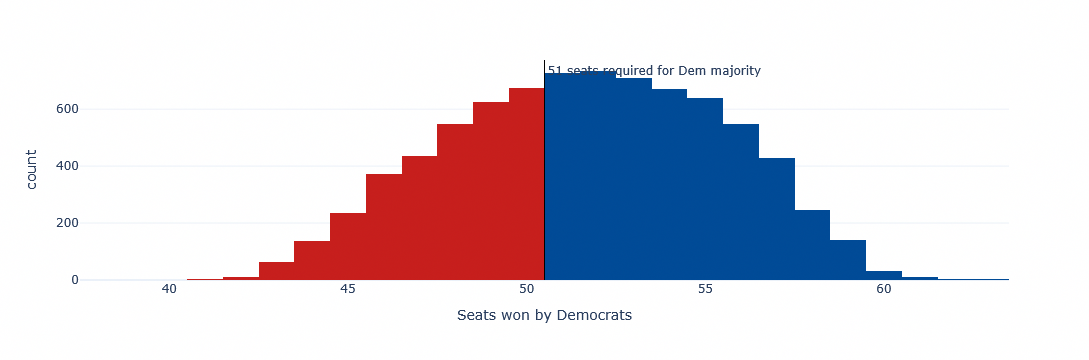

In [223]:
sims_hist = px.histogram(seat_sims, x='seats', nbins=np.unique(seat_sims['seats']).shape[0]*2, color='winner',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},
                         labels={'seats':'Seats won by Democrats', 'winner': 'Winner'}, template='plotly_white')
sims_hist.update_traces(showlegend=False)
sims_hist.add_vline(x=50.5, line_width=1, line_color='black', annotation_text='51 seats required for Dem majority', 
                    annotation_position='top right')
sims_hist

In [224]:
output_ts = pd.read_csv('model_output/output_over_time.csv')
output_ts.head()

,date,y,geo,type
0,2026-09-27,51.348375,US Senate,seats
1,2026-09-27,58.600000,US Senate,chance
2,2026-09-27,3.816193,US Senate,seats_sd
3,2026-09-27,38.771876,AL,y_pred
4,2026-09-27,3.537242,AL,y_pred_sd


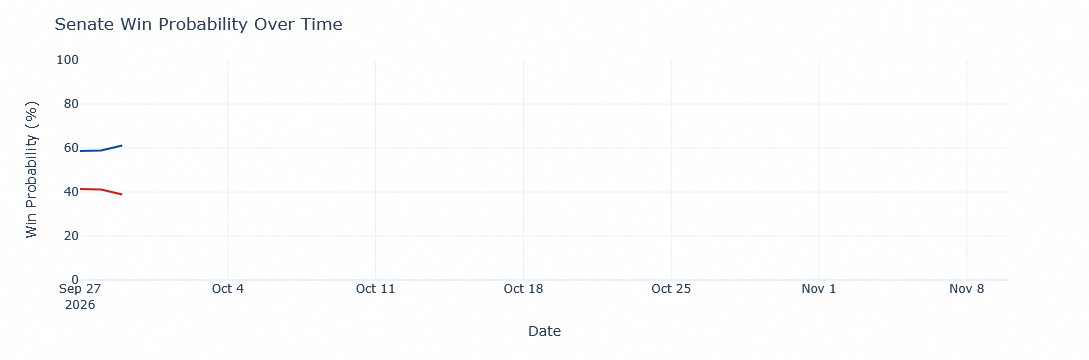

In [225]:
chance_over_time = output_ts[(output_ts['geo'] == 'US Senate') &
                             (output_ts['type'] == 'chance')]
chance_over_time['rep_chance'] = chance_over_time['y'].map(lambda x: 100 - x)
chance_over_time = chance_over_time.rename({'y': 'Democrats', 'rep_chance': 'Republicans'}, axis=1)
chance_time_ser = px.line(chance_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
chance_time_ser.update_traces(hovertemplate="%{y:.1f}%")
chance_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-09-27'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 100]),
    xaxis_title='Date',
    yaxis_title='Win Probability (%)',
    title=dict(text="Senate Win Probability Over Time"),
    hovermode="x",
    showlegend=False
)
chance_time_ser

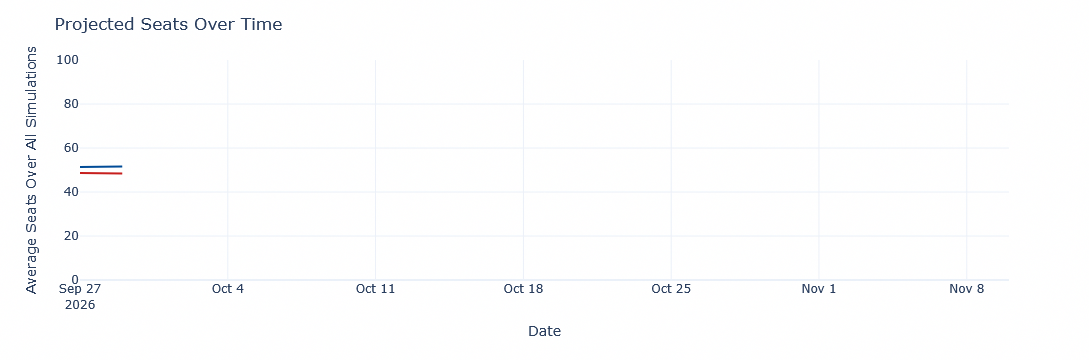

In [226]:
seats_over_time = output_ts[(output_ts['geo'] == 'US Senate') &
                             (output_ts['type'] == 'seats')]
seats_over_time['rep_seats'] = seats_over_time['y'].map(lambda x: 100 - x)
seats_over_time = seats_over_time.rename({'y': 'Democrats', 'rep_seats': 'Republicans'}, axis=1)
seats_time_ser = px.line(seats_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                        color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
seats_time_ser.update_traces(hovertemplate="%{y:.1f}")
seats_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-09-27'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 100]),
    xaxis_title='Date',
    yaxis_title='Average Seats Over All Simulations',
    title=dict(text="Projected Seats Over Time"),
    hovermode="x",
    showlegend=False
)
seats_time_ser

In [227]:
joblib.dump(sims_hist, 'display_data/sims_histogram.pkl')
joblib.dump(chance_time_ser, 'display_data/chance_time_ser.pkl')
joblib.dump(seats_time_ser, 'display_data/seats_time_ser.pkl')

['display_data/seats_time_ser.pkl']

In [228]:
# posterior prediction
post = pyreadr.read_r('model_output/labeled_posterior.RDS')[None]
post_untransp = post.copy()

In [229]:
post = post.T
post.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,...,7950,7951,7952,7953,7954,7955,7956,7957,7958,7959,7960,7961,7962,7963,7964,7965,7966,7967,7968,7969,7970,7971,7972,7973,7974,7975,7976,7977,7978,7979,7980,7981,7982,7983,7984,7985,7986,7987,7988,7989,7990,7991,7992,7993,7994,7995,7996,7997,7998,7999
AL,-7.523486,-13.517409,-11.739435,-11.686084,-9.427757,-13.222962,-11.405396,-5.340728,-12.396095,-17.080939,-1.157258,-13.341074,-11.241175,-11.490448,-11.913612,-9.069827,-9.573839,-12.431750,-10.035373,-7.428625,-12.756541,-8.759270,-6.788817,-9.397518,-8.897318,-14.137460,-13.679837,-7.989258,-13.059280,-12.604429,-10.127622,-11.675696,-11.449386,-8.053172,-15.893086,-14.990080,-7.612741,-10.934809,-8.749683,-12.213660,-10.722392,-8.777008,-13.747681,-10.637104,-12.980003,-13.323657,-12.886659,-15.130701,-7.468464,-11.264016,...,-11.545881,-10.911076,-10.039882,-14.927799,-7.218906,-11.489022,-12.968738,-7.796199,-12.305028,-8.008300,-16.140432,-16.125009,-10.519871,-7.171426,-17.466629,-6.914292,-16.320069,-2.898122,-12.365211,-8.529467,-11.664512,-9.887453,-4.235262,-21.442846,-3.008856,-14.547831,-11.863092,-13.238150,-8.155313,-12.227943,-10.852907,-12.490764,-10.974330,-7.835951,-16.588117,-12.405603,-10.991557,-18.539563,-10.387132,-9.674568,-10.780969,-14.207319,-10.572288,-10.252872,-12.033243,-13.143039,-14.841472,-10.119738,-12.514188,-12.115684
AK,0.274994,5.466018,-0.246405,5.371137,-1.117121,4.450359,4.938466,5.379991,-0.718797,-5.762228,10.712885,0.321390,-1.124126,6.411939,-1.026676,2.929067,5.552090,4.523950,-0.546733,2.653135,6.651970,4.227669,2.116215,5.007534,4.547004,1.305338,2.259752,3.297464,-1.053339,1.485449,3.308437,5.439773,6.890610,8.238437,2.669533,-0.315311,3.300588,0.013539,-1.121714,2.855944,-1.245872,3.432932,6.825089,4.016941,2.552001,-1.759662,0.862601,2.889806,1.938256,4.167766,...,3.926892,2.726671,9.816795,-0.594648,7.345592,2.646091,1.123873,3.459307,-1.582779,10.310293,2.153387,-1.140937,6.838667,3.121645,3.724743,1.301941,4.890020,1.833227,-0.831038,7.284631,1.396543,3.059666,8.319191,-0.084972,3.946019,-2.511948,6.135604,4.799746,3.287003,0.816614,-3.387476,5.121040,-0.922073,5.758296,1.579071,2.852775,3.127589,7.089404,3.832155,3.766323,0.010655,4.114626,3.821778,0.062836,3.820723,0.644289,1.622627,0.469678,3.259908,1.484107
AR,-11.090106,-12.866763,-9.255420,-11.930845,-10.720948,-8.925599,-9.975674,-6.532700,-15.130288,-14.882891,-2.080744,-12.633863,-13.493156,-8.008553,-12.977193,-11.618944,-10.948539,-9.453334,-11.808816,-8.156993,-12.138791,-11.612264,-7.923688,-8.092187,-12.323254,-9.740806,-12.171515,-8.804735,-12.152054,-11.946334,-9.303709,-10.020336,-7.440336,-8.198102,-14.374498,-13.836310,-7.099436,-10.638948,-12.156755,-11.225306,-11.288116,-7.164993,-12.975980,-14.811121,-13.451278,-11.660314,-9.785677,-14.758190,-11.650547,-12.622770,...,-13.670646,-12.274910,-8.911390,-14.272144,-4.654196,-13.122404,-13.502760,-12.233345,-11.080127,-4.790503,-15.415512,-13.001122,-9.026152,-8.379430,-14.319696,-5.507870,-16.297709,-1.977995,-10.109096,-9.384226,-12.637740,-7.162941,-5.699165,-16.307013,-4.163596,-17.286579,-9.951971,-16.967937,-6.084338,-10.579041,-9.970784,-11.701640,-10.422804,-3.287053,-18.341692,-10.454201,-8.493327,-13.245696,-6.851432,-12.918868,-11.962944,-11.527166,-9.419975,-7.949467,-12.115915,-14.156883,-17.804412,-12.072177,-8.510560,-11.593403
CO,11.660501,12.440414,7.513530,14.366124,9.121123,12.801291,14.606411,13.495701,11.072538,7.396128,13.566012,14.052252,11.168592,16.432655,8.180270,15.911931,13.970853,12.053861,7.065739,6.332273,13.192848,18.948083,10.154721,16.691752,13.943404,11.737595,11.563424,20.313911,7.980219,13.775215,14.334732,10.716059,9.632547,10.740387,12.018242,6.066959,16.573030,11.463162,15.678086,9.465301,13.306916,12.287665,11.919773,13.858995,10.855227,11.992309,7.908527,11.373139,12.650417,9.794987,...,14.067137,8.898889,17.670861,10.495

In [230]:
sim_corr = post_untransp.corr()

In [231]:
sim_corr.head()

,AL,AK,AR,CO,DE,FL,GA,ID,IL,IA,KS,KY,LA,ME,MA,MI,MN,MS,MT,NE,NH,NJ,NM,NC,OH,OK,OR,RI,SC,SD,TN,TX,VA,WV,WY
AL,1.000000,0.519363,0.740550,0.489768,0.497621,0.706709,0.532813,0.737648,0.709017,0.745065,0.740077,0.541603,0.752412,0.739237,0.523671,0.735548,0.709848,0.744317,0.701006,0.727068,0.505665,0.506827,0.509878,0.707639,0.508475,0.758782,0.508386,0.492560,0.493034,0.513895,0.559370,0.705008,0.506795,0.742030,0.739767
AK,0.519363,1.000000,0.517287,0.522246,0.525590,0.500952,0.559602,0.526537,0.503755,0.518191,0.518259,0.566279,0.524472,0.511273,0.561197,0.512150,0.500048,0.517795,0.498268,0.515263,0.561282,0.539719,0.553694,0.497741,0.551728,0.521231,0.547475,0.549604,0.537861,0.541869,0.597543,0.507411,0.544813,0.520852,0.519557
AR,0.740550,0.517287,1.000000,0.487450,0.500017,0.703788,0.527586,0.736834,0.700064,0.741733,0.738085,0.537271,0.742270,0.732045,0.523340,0.729092,0.700637,0.725901,0.692792,0.721741,0.509269,0.500558,0.502714,0.705361,0.504688,0.744342,0.501887,0.496632,0.495593,0.515437,0.557044,0.702514,0.498889,0.735937,0.735118
CO,0.489768,0.522246,0.487450,1.000000,0.708960,0.654164,0.550487,0.498027,0.655197,0.503331,0.488219,0.549460,0.503987,0.486635,0.537699,0.487266,0.643130,0.493843,0.652538,0.477967,0.710998,0.715800,0.720383,0.647337,0.706165,0.499977,0.710496,0.702141,0.699289,0.530991,0.571438,0.656279,0.703965,0.496869,0.494065
DE,0.497621,0.525590,0.500017,0.708960,1.000000,0.667635,0.543017,0.504836,0.665183,0.508875,0.499961,0.547759,0.503507,0.501962,0.548801,0.501620,0.663574,0.499260,0.663250,0.489584,0.718913,0.725942,0.729484,0.661319,0.715923,0.515662,0.710044,0.712502,0.709562,0.521174,0.577954,0.662021,0.719024,0.499435,0.509318


In [232]:
post.shape

(35, 8000)

In [233]:
def get_tipping_point(sim):
    """
    :param sim: Series representing one posterior draw or "simulation"
    :type sim: pd.Series
    """
    seats_won_dem = np.sum(sim > 0)
    if seats_won_dem >= 51 - dem_uncont: # Democrats win House in this draw
        sim = sim.sort_values(ascending=True)
        won_seats = sim[sim > 0]
        seat_margin = seats_won_dem - (51 - dem_uncont)
    else: # Republicans win House in this draw
        sim = sim.sort_values(ascending=False)
        won_seats = sim[sim < 0]
        seat_margin = (100 - seats_won_dem - dem_uncont - rep_uncont) - (50 - rep_uncont)
    return won_seats.iloc[seat_margin - 1], won_seats.index[seat_margin - 1]

In [234]:
tipping_points = np.array([]) # tipping point for *each sim*

for i in tqdm(range(post.shape[1])):
    sim = post.iloc[:, i]
    _, tp_seat = get_tipping_point(sim)
    tipping_points = np.append(tipping_points, tp_seat)

tipping_points

100%|████████████████████████████████████████████████████████████████████████████| 8000/8000 [00:07<00:00, 1139.82it/s]


array(['IA', 'MI', 'TX', ..., 'IA', 'WY', 'AK'],
      shape=(8000,), dtype='<U32')

In [235]:
data = pd.read_csv('../../model_output/senate_predictions.csv')
data.head()

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.373272,0,0,32.000000,0.048638,47.000000,0.048638,East South Central,2026,0.000000,0.0,0.000000,5,Senate,0.142508,0.048638,0.220541,15.000000,-20.253170,-49.622498,0,-99.244996,39.072224,3.537264,0.0875,1,32.264544,46.142300
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.373272,0,1,49.473113,2.102333,48.488694,2.102333,Pacific,2026,0.000000,0.0,0.000000,5,Senate,9989.631483,2.102333,1.449942,-0.984419,-3.537333,49.948144,-1,99.896288,52.990696,3.400053,81.2500,2,46.334472,59.763568
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.373272,0,1,38.189521,0.447408,49.190029,0.447408,West South Central,2026,0.000000,0.0,0.000000,5,Senate,1718.789084,0.447408,0.668885,11.000508,-21.247771,-8.541719,-1,-17.083438,39.340890,3.568307,0.1375,3,32.239047,46.240122
3,3,Colorado,John Hickenlooper,Mark Baisley,True,False,D,CO,"HICKENLOOPER, JOHN W.","BAISLEY, MARK",5806791.50,134872.30,5941663.80,97.730058,2.269942,5.964568,55.646542,73.317129,2.765032,16.968086,3.741915,0.400190,45.698090,4966936,806778,5773714,86.026707,13.973293,0.987401,-9.373272,1,0,0.000000,0.000000,0.000000,0.000000,Mountain,2026,0.367879,0.0,0.367879,0,Senate,9551.164309,0.000000,0.000000,0.000000,21.302408,47.730058,1,95.460117,62.013485,3.504067,99.9625,4,55.225686,68.918405
4,4,Delaware,Chris Coons,Michael Katz,True,False,D,DE,"COONS, CHRISTOPHER A.","KATZ, MICHAEL S DR.",1989694.63,29805.27,2019499.90,98.524126,1.475874,8.011194,57.479236,66.185281,3.007143,6.848324,21.107845,0.148276,35.764628,817817,172131,989948,82.612117,17.387883,0.987401,-9.373272,1,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.000000,0.0,0.000000,2,Senate,9707.003443,0.000000,0.000000,0.000000,25.395661,48.524126,1,97.048252,63.556712,3.504509,99.9875,5,56.717974,70.514634


In [236]:
data['tipping_point_prob'] = data['state_po'].map(lambda x: np.mean(tipping_points == x) * 100)
data.head()

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.373272,0,0,32.000000,0.048638,47.000000,0.048638,East South Central,2026,0.000000,0.0,0.000000,5,Senate,0.142508,0.048638,0.220541,15.000000,-20.253170,-49.622498,0,-99.244996,39.072224,3.537264,0.0875,1,32.264544,46.142300,0.0000
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.373272,0,1,49.473113,2.102333,48.488694,2.102333,Pacific,2026,0.000000,0.0,0.000000,5,Senate,9989.631483,2.102333,1.449942,-0.984419,-3.537333,49.948144,-1,99.896288,52.990696,3.400053,81.2500,2,46.334472,59.763568,5.6625
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.373272,0,1,38.189521,0.447408,49.190029,0.447408,West South Central,2026,0.000000,0.0,0.000000,5,Senate,1718.789084,0.447408,0.668885,11.000508,-21.247771,-8.541719,-1,-17.083438,39.340890,3.568307,0.1375,3,32.239047,46.240122,0.0000
3,3,Colorado,John Hickenlooper,Mark Baisley,True,False,D,CO,"HICKENLOOPER, JOHN W.","BAISLEY, MARK",5806791.50,134872.30,5941663.80,97.730058,2.269942,5.964568,55.646542,73.317129,2.765032,16.968086,3.741915,0.400190,45.698090,4966936,806778,5773714,86.026707,13.973293,0.987401,-9.373272,1,0,0.000000,0.000000,0.000000,0.000000,Mountain,2026,0.367879,0.0,0.367879,0,Senate,9551.164309,0.000000,0.000000,0.000000,21.302408,47.730058,1,95.460117,62.013485,3.504067,99.9625,4,55.225686,68.918405,0.1250
4,4,Delaware,Chris Coons,Michael Katz,True,False,D,DE,"COONS, CHRISTOPHER A.","KATZ, MICHAEL S DR.",1989694.63,29805.27,2019499.90,98.524126,1.475874,8.011194,57.479236,66.185281,3.007143,6.848324,21.107845,0.148276,35.764628,817817,172131,989948,82.612117,17.387883,0.987401,-9.373272,1,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.000000,0.0,0.000000,2,Senate,9707.003443,0.000000,0.000000,0.000000,25.395661,48.524126,1,97.048252,63.556712,3.504509,99.9875,5,56.717974,70.514634,0.7625


In [237]:
data.sort_values('tipping_point_prob', ascending=False).head(5)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
15,15,Michigan,Abdul El-Sayed,Mike J. Rogers,False,False,D,MI,"EL-SAYED, ABDUL","ROGERS, MICHAEL J",14408058.06,6831818.66,21239876.72,67.834942,32.165058,-0.192456,49.278763,77.709102,2.333008,4.148895,12.968600,0.319413,32.445883,7404258,2673073,10077331,73.474395,26.525605,0.987401,-9.373272,0,0,47.448205,8.177246,44.721817,8.177246,East North Central,2026,0.0,0.00000,0.00000,2,Senate,4601.579360,8.177246,2.859588,-2.726388,8.988360,17.834942,0,35.669884,50.768890,3.538649,58.5625,16,43.993470,57.765273,11.3500
31,31,Texas,James Talarico,Ken Paxton,False,False,R,TX,"TALARICO, JAMES","PAXTON, WARREN KENNETH JR.",65585741.88,9020177.98,74605919.86,87.909568,12.090432,-5.916874,43.060966,48.286718,4.530331,31.642337,13.173480,0.180615,33.823334,24400697,4744808,29145505,83.720275,16.279725,0.987401,-9.373272,0,0,48.027254,6.387558,45.057193,6.387558,West South Central,2026,0.0,0.25284,-0.25284,6,Senate,7728.092153,6.387558,2.527362,-2.970061,-2.460476,37.909568,0,75.819136,51.251969,3.626707,63.5625,32,44.165300,58.450094,10.5625
13,13,Maine,Troy Jackson,Susan Collins,False,True,R,ME,no_match,"COLLINS, SUSAN M.",0.00,10501136.60,10501136.60,0.000000,100.000000,3.820912,53.544306,94.249770,0.897865,1.689465,0.930085,0.342309,36.189622,526309,836050,1362359,38.632181,61.367819,0.987401,-9.373272,0,1,48.007447,4.272143,45.913710,4.272143,New England,2026,0.0,0.00000,0.00000,3,Senate,0.000000,4.272143,2.066916,-2.093737,17.015096,-50.000000,-1,-100.000000,50.223701,3.583506,52.0250,14,43.119580,57.289277,9.9375
9,9,Iowa,Josh Turek,Ashley Hinson,False,False,R,IA,"TUREK, JOSHUA","ARENHOLZ, ASHLEY HINSON",5835816.67,5267628.55,11103445.22,52.558612,47.441388,-6.092833,43.277201,88.847514,1.696738,4.401391,3.028533,0.168574,31.423453,2014831,1175538,3190369,63.153541,36.846459,0.987401,-9.373272,0,0,46.039942,4.530107,45.185154,4.530107,West North Central,2026,0.0,0.00000,0.00000,3,Senate,2762.407675,4.530107,2.128405,-0.854788,-2.812395,2.558612,0,5.117224,49.785786,3.515051,46.6250,10,42.799479,56.660649,9.6750
24,24,Ohio,Sherrod Brown,Jon Husted,False,True,R,OH,"BROWN, SHERROD","HUSTED, JON",31146133.40,6280012.05,37426145.45,83.220254,16.779746,-5.266554,44.343385,80.925356,1.708882,3.291326,11.486903,0.076606,31.487184,9001099,2798349,11799448,76.284069,23.715931,0.987401,-9.373272,0,1,48.771885,2.320818,43.407525,2.320818,East North Central,2026,0.0,0.00000,0.00000,2,Senate,6925.610718,2.320818,1.523423,-5.364360,-1.159836,33.220254,-1,66.440509,51.292135,3.466262,64.8000,25,44.363464,58.154833,8.5750


In [238]:
def get_rating(dem_chance):
    if dem_chance > 100:
        raise ValueError('Invalid win chance.')
    if dem_chance > 95:
        return 'Safe D'
    elif dem_chance >= 90:
        return 'Very Likely D'
    elif dem_chance >= 75:
        return 'Likely D'
    elif dem_chance >= 65:
        return 'Lean D'
    elif dem_chance >= 60:
        return 'Tilt D'
    elif dem_chance >= 40:
        return 'Tossup'
    elif dem_chance >= 35:
        return 'Tilt R'
    elif dem_chance >= 25:
        return 'Lean R'
    elif dem_chance >= 10:
        return 'Likely R'
    elif dem_chance >= 5:
        return 'Very Likely R'
    else:
        return 'Safe R'

def get_matchup(dem_cand, rep_cand, dem_inc_any, rep_inc_any):
    indie_d = ['Dan Osborn', 'Brian Bengs', 'Todd Achilles', 'Seth Bodnar']
    indie_r = []
    
    if dem_cand in indie_d:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (I)'
        dem_color = '#792ba6'
    else:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (D)'
        dem_color = '#366bbf'
    
    if rep_cand in indie_r:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (I)'
        rep_color = '#792ba6'
    else:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (R)'
        rep_color = '#e63929'

    return f'<b style="color:{dem_color};">' + dem_lab + f'</b> vs <b style="color:{rep_color};">' + rep_lab + '</b>'

In [239]:
data['rating'] = data['chance'].map(lambda x: get_rating(x))
for party in ['dem', 'rep']:
    data[f'{party}_cand'] = data[f'{party}_cand'].map(lambda x: 'TBD' if x[:3] == 'TBD' else x)
data['matchup'] = data[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                          x['dem_inc_any'], x['rep_inc_any']), axis=1)
data.head()

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.373272,0,0,32.000000,0.048638,47.000000,0.048638,East South Central,2026,0.000000,0.0,0.000000,5,Senate,0.142508,0.048638,0.220541,15.000000,-20.253170,-49.622498,0,-99.244996,39.072224,3.537264,0.0875,1,32.264544,46.142300,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b..."
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.373272,0,1,49.473113,2.102333,48.488694,2.102333,Pacific,2026,0.000000,0.0,0.000000,5,Senate,9989.631483,2.102333,1.449942,-0.984419,-3.537333,49.948144,-1,99.896288,52.990696,3.400053,81.2500,2,46.334472,59.763568,5.6625,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>..."
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.373272,0,1,38.189521,0.447408,49.190029,0.447408,West South Central,2026,0.000000,0.0,0.000000,5,Senate,1718.789084,0.447408,0.668885,11.000508,-21.247771,-8.541719,-1,-17.083438,39.340890,3.568307,0.1375,3,32.239047,46.240122,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<..."
3,3,Colorado,John Hickenlooper,Mark Baisley,True,False,D,CO,"HICKENLOOPER, JOHN W.","BAISLEY, MARK",5806791.50,134872.30,5941663.80,97.730058,2.269942,5.964568,55.646542,73.317129,2.765032,16.968086,3.741915,0.400190,45.698090,4966936,806778,5773714,86.026707,13.973293,0.987401,-9.373272,1,0,0.000000,0.000000,0.000000,0.000000,Mountain,2026,0.367879,0.0,0.367879,0,Senate,9551.164309,0.000000,0.000000,0.000000,21.302408,47.730058,1,95.460117,62.013485,3.504067,99.9625,4,55.225686,68.918405,0.1250,Safe D,"<b style=""color:#366bbf;"">John Hickenlooper* (..."
4,4,Delaware,Chris Coons,Michael Katz,True,False,D,DE,"COONS, CHRISTOPHER A.","KATZ, MICHAEL S DR.",1989694.63,29805.27,2019499.90,98.524126,1.475874,8.011194,57.479236,66.185281,3.007143,6.848324,21.107845,0.148276,35.764628,817817,172131,989948,82.612117,17.387883,0.987401,-9.373272,1,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.000000,0.0,0.000000,2,Senate,9707.003443,0.000000,0.000000,0.000000,25.395661,48.524126,1,97.048252,63.556712,3.504509,99.9875,5,56.717974,70.514634,0.7625,Safe D,"<b style=""color:#366bbf;"">Chris Coons* (D)</b>..."


In [240]:
data['projected_winner'] = data['chance'].map(lambda x: 'D' if x > 50 else 'R')
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.373272,0,0,32.000000,0.048638,47.000000,0.048638,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.048638,0.220541,15.000000,-20.253170,-49.622498,0,-99.244996,39.072224,3.537264,0.0875,1,32.264544,46.142300,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.373272,0,1,49.473113,2.102333,48.488694,2.102333,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.102333,1.449942,-0.984419,-3.537333,49.948144,-1,99.896288,52.990696,3.400053,81.2500,2,46.334472,59.763568,5.6625,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.373272,0,1,38.189521,0.447408,49.190029,0.447408,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.447408,0.668885,11.000508,-21.247771,-8.541719,-1,-17.083438,39.340890,3.568307,0.1375,3,32.239047,46.240122,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R


In [241]:
data['hold'] = data['projected_winner'] ==  data['current_party']
data['flip'] = data['hold'].map(lambda x: not x)
data['flip_indic'] = data['flip'].map(lambda x: 'Flip' if x else '')
#data['flip'] = data['flip'].map(lambda x: 'Yes' if x else 'No')
data.head(2)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.373272,0,0,32.000000,0.048638,47.000000,0.048638,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.048638,0.220541,15.000000,-20.253170,-49.622498,0,-99.244996,39.072224,3.537264,0.0875,1,32.264544,46.142300,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.373272,0,1,49.473113,2.102333,48.488694,2.102333,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.102333,1.449942,-0.984419,-3.537333,49.948144,-1,99.896288,52.990696,3.400053,81.2500,2,46.334472,59.763568,5.6625,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip


In [242]:
data['projected_2p_margin'] = data['y_pred'].map(lambda y_pred: f'D+{y_pred - (100-y_pred):.1f}' if y_pred > 50 else f'R+{(100-y_pred) - y_pred:.1f}')
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.373272,0,0,32.000000,0.048638,47.000000,0.048638,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.048638,0.220541,15.000000,-20.253170,-49.622498,0,-99.244996,39.072224,3.537264,0.0875,1,32.264544,46.142300,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+21.9
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.373272,0,1,49.473113,2.102333,48.488694,2.102333,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.102333,1.449942,-0.984419,-3.537333,49.948144,-1,99.896288,52.990696,3.400053,81.2500,2,46.334472,59.763568,5.6625,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+6.0
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.373272,0,1,38.189521,0.447408,49.190029,0.447408,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.447408,0.668885,11.000508,-21.247771,-8.541719,-1,-17.083438,39.340890,3.568307,0.1375,3,32.239047,46.240122,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R,True,False,,R+21.3


In [243]:
data['rep_chance'] = data['chance'].map(lambda x: 100 - x)
data['rounded_dem_chance'] = data['chance'].map(lambda x: np.round(x, 1))
data['rounded_rep_chance'] = data['rep_chance'].map(lambda x: np.round(x, 1))
data['disp_dem_chance'] = data['rounded_dem_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data['disp_rep_chance'] = data['rounded_rep_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.373272,0,0,32.000000,0.048638,47.000000,0.048638,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.048638,0.220541,15.000000,-20.253170,-49.622498,0,-99.244996,39.072224,3.537264,0.0875,1,32.264544,46.142300,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+21.9,99.9125,0.1,99.9,<1%,>99%
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.373272,0,1,49.473113,2.102333,48.488694,2.102333,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.102333,1.449942,-0.984419,-3.537333,49.948144,-1,99.896288,52.990696,3.400053,81.2500,2,46.334472,59.763568,5.6625,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+6.0,18.7500,81.2,18.8,81.2%,18.8%
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.373272,0,1,38.189521,0.447408,49.190029,0.447408,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.447408,0.668885,11.000508,-21.247771,-8.541719,-1,-17.083438,39.340890,3.568307,0.1375,3,32.239047,46.240122,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R,True,False,,R+21.3,99.8625,0.1,99.9,<1%,>99%


In [244]:
data['swing_24_to_26'] = data['y_pred'].astype(float).map(lambda x: x - (100 - x)) - data['dem_2p_24'].astype(float).map(lambda x: x - (100 - x))
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.373272,0,0,32.000000,0.048638,47.000000,0.048638,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.048638,0.220541,15.000000,-20.253170,-49.622498,0,-99.244996,39.072224,3.537264,0.0875,1,32.264544,46.142300,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+21.9,99.9125,0.1,99.9,<1%,>99%,9.025672
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.373272,0,1,49.473113,2.102333,48.488694,2.102333,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.102333,1.449942,-0.984419,-3.537333,49.948144,-1,99.896288,52.990696,3.400053,81.2500,2,46.334472,59.763568,5.6625,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+6.0,18.7500,81.2,18.8,81.2%,18.8%,19.674517
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.373272,0,1,38.189521,0.447408,49.190029,0.447408,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.447408,0.668885,11.000508,-21.247771,-8.541719,-1,-17.083438,39.340890,3.568307,0.1375,3,32.239047,46.240122,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R,True,False,,R+21.3,99.8625,0.1,99.9,<1%,>99%,10.021766


In [245]:
data['disp_24_to_26_swing'] = data['swing_24_to_26'].map(lambda x: f'D+{x:.1f}' if x > 0 else f'R+{abs(x):.1f}')
data.head(2)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26,disp_24_to_26_swing
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.373272,0,0,32.000000,0.048638,47.000000,0.048638,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.048638,0.220541,15.000000,-20.253170,-49.622498,0,-99.244996,39.072224,3.537264,0.0875,1,32.264544,46.142300,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+21.9,99.9125,0.1,99.9,<1%,>99%,9.025672,D+9.0
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.373272,0,1,49.473113,2.102333,48.488694,2.102333,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.102333,1.449942,-0.984419,-3.537333,49.948144,-1,99.896288,52.990696,3.400053,81.2500,2,46.334472,59.763568,5.6625,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+6.0,18.7500,81.2,18.8,81.2%,18.8%,19.674517,D+19.7


In [246]:
tab_data = data[['state', 'dem_cand', 'rep_cand', 'rating', 'disp_dem_chance', 'disp_rep_chance', 'projected_2p_margin', 'disp_24_to_26_swing',
                 'tipping_point_prob']]
for party in ['dem', 'rep']:
    tab_data[f'disp_{party}_chance'] = tab_data[f'disp_{party}_chance'].map(lambda x: f'<p style="color:{'blue' if party == 'dem' else 'red'};">{x}</p>')
    tab_data[f'{party}_cand'] = tab_data[f'{party}_cand'].map(lambda x: f'{x} (Ind)' if x in ['Dan Osborn', 'Brian Bengs', 
                                                                                              'Todd Achilles', 'Seth Bodnar'] else x)
tab_data = tab_data.rename({
    'state': 'State',
    'dem_cand': 'Democrat',
    'rep_cand': 'Republican',
    'rating': 'Rating',
    'disp_dem_chance': 'Dem Chance',
    'disp_rep_chance': 'Rep Chance',
    'projected_2p_margin': 'Projected Margin',
    'tipping_point_prob': 'Tipping Point Chance',
    'disp_24_to_26_swing': 'Swing from 2024 Pres'
}, axis=1)
tab_data.head()

,State,Democrat,Republican,Rating,Dem Chance,Rep Chance,Projected Margin,Swing from 2024 Pres,Tipping Point Chance
0,Alabama,Everett Weiss,Barry Moore,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+21.9,D+9.0,0.0000
1,Alaska,Mary Peltola,Dan S. Sullivan,Likely D,"<p style=""color:blue;"">81.2%</p>","<p style=""color:red;"">18.8%</p>",D+6.0,D+19.7,5.6625
2,Arkansas,Hallie Shoffner,Tom Cotton,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+21.3,D+10.0,0.0000
3,Colorado,John Hickenlooper,Mark Baisley,Safe D,"<p style=""color:blue;"">>99%</p>","<p style=""color:red;""><1%</p>",D+24.0,D+12.7,0.1250
4,Delaware,Chris Coons,Michael Katz,Safe D,"<p style=""color:blue;"">>99%</p>","<p style=""color:red;""><1%</p>",D+27.1,D+12.2,0.7625


In [247]:
data['rep_pred'] = data['y_pred'].map(lambda x: 100 - x)
data['projected_2p_margin_number'] = data['rep_pred'] - data['y_pred']
data['proj_seat_lean'] = data['projected_2p_margin_number'] - data['generic_ballot_avg']
sv_bias = float(data.sort_values('tipping_point_prob', ascending=False).reset_index().loc[0, 'proj_seat_lean']) # Seats-votes bias, + = R, - = D
sv_bias

7.835490920707745

In [248]:
topline_stats = pd.read_csv('display_data/topline_stats.csv')
if 'sv_bias' in topline_stats['vars'].values:
    topline_stats = topline_stats[topline_stats['vars'] != 'sv_bias']
topline_stats = pd.concat([topline_stats, pd.DataFrame({'vars': ['sv_bias'], 'x': sv_bias})], axis=0)
topline_stats.to_csv('display_data/topline_stats.csv')
topline_stats

,vars,x
0,means_seats_tot,51.640375
1,chamber_win_chance,61.175000
0,sv_bias,7.835491


In [249]:
mean_seats_tot = topline_stats[topline_stats['vars'] == 'means_seats_tot']['x'].values[0]
chamber_win_chance = topline_stats[topline_stats['vars'] == 'chamber_win_chance']['x'].values[0]

In [250]:
chances = topline_stats[topline_stats['vars'] == 'chamber_win_chance'].set_index(['vars']).T
chances['Republicans'] = chances['chamber_win_chance'].map(lambda x: 100 - x)
chances = chances.rename({'chamber_win_chance': 'Democrats'}, axis=1).T.reset_index()
chances = chances.rename({'x': 'Win Probability'}, axis=1)
seats = topline_stats[topline_stats['vars'] == 'means_seats_tot'].set_index(['vars']).T
seats['Republicans'] = seats['means_seats_tot'].map(lambda x: 100 - x)
seats = seats.rename({'means_seats_tot': 'Democrats'}, axis=1).T.reset_index().rename({'x': 'Seat Share'}, axis=1)
summary_stats = pd.merge(left=chances, right=seats, on='vars', how='inner').rename({'vars': 'Party'}, axis=1)
summary_stats.to_csv('display_data/summary_stats.csv')
summary_stats

,Party,Win Probability,Seat Share
0,Democrats,61.175,51.640375
1,Republicans,38.825,48.359625


In [251]:
incl_cols = ['state', 'dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any', 'rating', 'chance', 'disp_dem_chance',
            'disp_rep_chance', 'projected_2p_margin', 'y_pred', 'flip_indic', 'matchup', 'swing_24_to_26', 'disp_24_to_26_swing']
disp_data = data[incl_cols]

In [252]:
rating_ts = output_ts[output_ts['type'] == 'chance']
rating_ts['rating'] = rating_ts['y'].map(get_rating)
rating_ts['date'] = pd.to_datetime(rating_ts['date'])
rating_ts.head()

,date,y,geo,type,rating
1,2026-09-27,58.6000,US Senate,chance,Tossup
5,2026-09-27,0.0500,AL,chance,Safe R
10,2026-09-27,79.8875,AK,chance,Likely D
15,2026-09-27,0.1250,AR,chance,Safe R
20,2026-09-27,99.9625,CO,chance,Safe D


In [253]:
## Alert when there's a rating change
today_date = rating_ts['date'].max()
yesterday = rating_ts[rating_ts['date'] != today_date]['date'].max()

today_ratings = rating_ts[rating_ts['date'] == today_date]
yester_ratings = rating_ts[rating_ts['date'] == yesterday]
compare_df = pd.merge(left=today_ratings, right=yester_ratings, on='geo', how='left', suffixes=['_t', '_y'])
compare_df.head()

,date_t,y_t,geo,type_t,rating_t,date_y,y_y,type_y,rating_y
0,2026-09-29,61.1750,US Senate,chance,Tilt D,2026-09-28,58.8250,chance,Tossup
1,2026-09-29,0.0875,AL,chance,Safe R,2026-09-28,0.0500,chance,Safe R
2,2026-09-29,81.2500,AK,chance,Likely D,2026-09-28,79.9750,chance,Likely D
3,2026-09-29,0.1375,AR,chance,Safe R,2026-09-28,0.1250,chance,Safe R
4,2026-09-29,99.9625,CO,chance,Safe D,2026-09-28,99.9625,chance,Safe D


In [254]:
## This is the cell that actually alerts when there's a rating change
if any(compare_df['rating_t'] != compare_df['rating_y']):
    changes_df = compare_df[compare_df['rating_t'] != compare_df['rating_y']][['geo', 'rating_y', 'rating_t']]
    print(changes_df)
else:
    print("No rating changes today!")

          geo  rating_y rating_t
0   US Senate    Tossup   Tilt D
11         KS  Likely R   Lean R
25         OH    Tossup   Tilt D


In [256]:
changes_df.shape

(3, 3)

In [255]:
disp_data.to_csv('display_data/choropleth_display_data.csv')
tab_data.to_csv('display_data/table_display_data.csv')
data.to_csv('display_data/all_data.csv')